# Preparation: import libraries and load data

In [1]:
import sys
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sksurv.util import Surv
import os
import joblib

from sksurv.metrics import concordance_index_censored
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold

import shap

In [2]:
seed = 71

In [3]:
# SELECTION OF NEEDED PARAMETERS
# THE ONLY OTHER BOX TO BE MODIFIED IS THE LIST OF FEATURES TO BE USED IN THE MODEL

# Indicate the outcome of interest ['OS','PSF']
outcome = 'PFS'
status = f'STATUS {outcome}'

# Indicate the model to be used ['CPH', 'ST', 'GBS', 'RSF', 'EST', 'SSVM']
file = "EST_none.joblib"

# Set this to True if you want to save figures/data, and False otherwise
save_output = True

In [4]:
# Load data
X_train = pd.read_excel("Data/X_train.xlsx").iloc[:, 1:]
X_test  = pd.read_excel("Data/X_test.xlsx").iloc[:, 1:]
y_train_df = pd.read_excel("Data/y_train.xlsx").iloc[:, 1:]
y_test_df  = pd.read_excel("Data/y_test.xlsx").iloc[:, 1:]
y_train_df = y_train_df.rename(columns={status: "event", outcome: "time"})
y_test_df = y_test_df.rename(columns={status: "event", outcome: "time"})
y_tr = Surv.from_dataframe("event", "time", y_train_df)
y_t  = Surv.from_dataframe("event", "time", y_test_df)

In [5]:
def cindex(y_true, y_pred):
    return concordance_index_censored(
        y_true["event"], y_true["time"], y_pred
    )[0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=31)

def stratify_labels(y):
    return y["event"].astype(int)

class SurvivalUnivariateSelector(BaseEstimator, TransformerMixin):
    def __init__(self, model, threshold=0.55, cv=3):
        self.model = model
        self.threshold = threshold
        self.cv = cv

    def fit(self, X, y):
        Xc = X.copy()
        self.selected_features_ = []

        skf = StratifiedKFold(n_splits=self.cv, shuffle=True, random_state=42)
        strat_labels = stratify_labels(y)

        for col in Xc.columns:
            scores = []

            for train_idx, val_idx in skf.split(Xc, strat_labels):
                X_tr, X_val = Xc.iloc[train_idx][[col]], Xc.iloc[val_idx][[col]]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = clone(self.model)
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)

                scores.append(cindex(y_val, preds))

            if np.mean(scores) > self.threshold:
                self.selected_features_.append(col)

        if len(self.selected_features_) == 0:
            self.selected_features_ = list(Xc.columns)

        return self

    def transform(self, X):
        Xc = X.copy()
        return Xc[self.selected_features_]

In [6]:
folder = file.replace(".joblib", "")
name, fs = folder.rsplit("_", 1)

# Load pipeline
pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
m = pipeline.named_steps.get("model", None)

features_model = m.feature_names_in_
if fs=="univ":
    X_tr = X_train[features_model]
    X_t = X_test[features_model]
else:
    X_tr = X_train
    X_t = X_test

In [7]:
# Arrays of risk scores predicted by the model

y_pred_train = m.predict(X_tr)
y_pred_test = m.predict(X_t)

In [8]:
# Expected values of the risk scores (= mean of the predicted values)

exp_value_tr = np.mean(y_pred_train)
print(f"Expected value TRAIN: {exp_value_tr.round(3)}")

exp_value_te = np.mean(y_pred_test)
print(f"Expected value TEST: {exp_value_te.round(3)}")

Expected value TRAIN: 72.11
Expected value TEST: 71.91


# Explainability analysis: building the explainer

In [9]:
# Train the explainer and generate explanations for the TEST set

explainer = shap.Explainer(m.predict, X_tr, seed=seed)
shap_values = explainer(X_t)

PermutationExplainer explainer: 115it [05:14,  2.83s/it]                         


Link the SHAP values to the corresponding original data (non-logarithmic and non-normalized), so that Explainability graphs refer to the original data

In [10]:
# Print the list of features selected by the feature selector
print(f'Features for training the model: \n{features_model} \n')

# Array with the original names of the selected features
features_original = np.array([n.removeprefix('log_') for n in features_model])
# Print the list of original selected features
print(f'Original features: \n{features_original}')

Features for training the model: 
['Sex' 'Age' 'Nefrectomy' 'M+ at diagnosis' 'IMDC Score at diagnosis'
 'TKI' 'Hb at baseline' 'IMDC Score at baseline IO' 'KPS'
 'Lymph nodes metastases' 'Visceral metastases' 'Bone metastases'
 'Platelets at baseline' 'PLR at baseline' 'SII at baseline'
 'Histology_clearcell' 'Nivolumab_2ndline' 'log_Leukocytes at baseline'
 'log_Neutrophils at baseline' 'log_Lymphocytes at baseline'
 'log_Monocytes at baseline' 'log_Eosinophils at baseline'
 'log_NLR at baseline'] 

Original features: 
['Sex' 'Age' 'Nefrectomy' 'M+ at diagnosis' 'IMDC Score at diagnosis'
 'TKI' 'Hb at baseline' 'IMDC Score at baseline IO' 'KPS'
 'Lymph nodes metastases' 'Visceral metastases' 'Bone metastases'
 'Platelets at baseline' 'PLR at baseline' 'SII at baseline'
 'Histology_clearcell' 'Nivolumab_2ndline' 'Leukocytes at baseline'
 'Neutrophils at baseline' 'Lymphocytes at baseline'
 'Monocytes at baseline' 'Eosinophils at baseline' 'NLR at baseline']


In [11]:
# Load the corresponding non-logarithmised and non-normalised data
X_test_explainability = pd.read_excel('Data/X_test_expl.xlsx')

# Keep only the original features corresponding to those selected by the feature selector
X_test_explainability = X_test_explainability.loc[:,features_original]
X_test_explainability.columns

Index(['Sex', 'Age', 'Nefrectomy', 'M+ at diagnosis',
       'IMDC Score at diagnosis', 'TKI', 'Hb at baseline',
       'IMDC Score at baseline IO', 'KPS', 'Lymph nodes metastases',
       'Visceral metastases', 'Bone metastases', 'Platelets at baseline',
       'PLR at baseline', 'SII at baseline', 'Histology_clearcell',
       'Nivolumab_2ndline', 'Leukocytes at baseline',
       'Neutrophils at baseline', 'Lymphocytes at baseline',
       'Monocytes at baseline', 'Eosinophils at baseline', 'NLR at baseline'],
      dtype='object')

In [12]:
# Set the feature names in the SHAP values
for i, c in enumerate(features_original):
    shap_values.feature_names[i] = c

# Link the SHAP values to the corresponding original data
shap_values.data = X_test_explainability.values

In [13]:
# Save the explainer and the SHAP values

if save_output:
    with open(f'Explainability/{folder}/explainer.pkl', 'wb') as f:
        pickle.dump(explainer, f)
    with open(f'Explainability/{folder}/shap_values.pkl', 'wb') as f:
        pickle.dump(shap_values, f)

# Explainability plots - test set

## Beeswarm plots

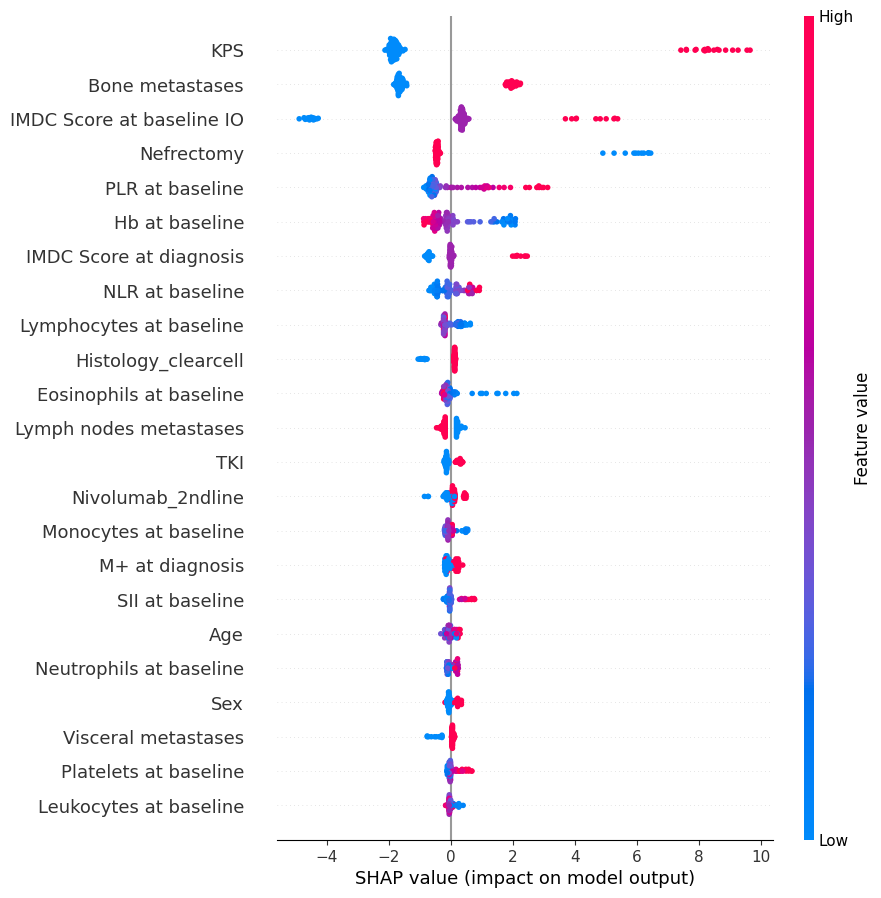

In [14]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=X_tr.shape[1], show=False)
if save_output:
    plt.savefig(f'Explainability/{folder}/Beeswarm_complete.png', format='png', dpi=300, bbox_inches='tight')

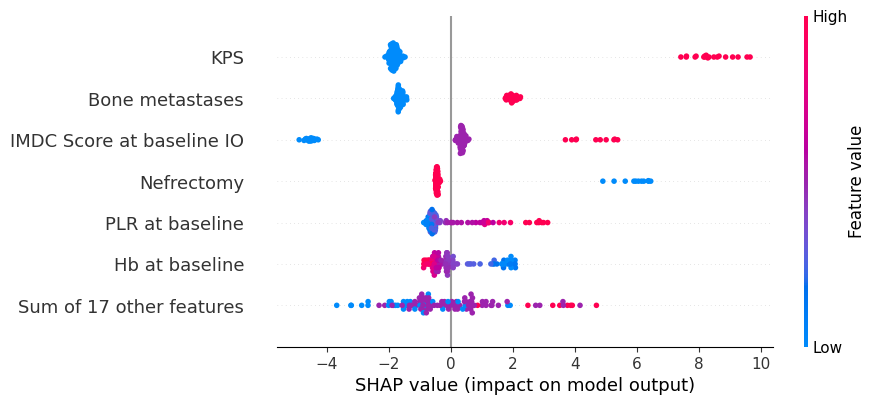

In [15]:
# Plot the SHAP values for the first 6 most important features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=7, show=False)
if save_output:
    plt.savefig(f'Explainability/{folder}/Beeswarm_reduced.png', format='png', dpi=300, bbox_inches='tight')